In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
df = pd.read_csv("/content/amazon_ecommerce_1M_clean.csv")

/tmp/ipykernel_1019/1356880247.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/amazon_ecommerce_1M_clean.csv")


In [8]:
print(df.shape)

(41859, 25)


In [9]:
print(df.head)

<bound method NDFrame.head of        user_id product_id     category subcategory    brand     price  \
0      U356787     P39256  Electronics      Mobile      H&M  33090.51   
1      U198246     P38657       Sports     Outdoor  Samsung   9368.97   
2      U539898     P38893       Sports     Fitness      H&M  14756.85   
3      U325772     P54118       Beauty      Makeup     Sony    668.83   
4      U865179     P70217         Home       Decor     Sony  10881.29   
...        ...        ...          ...         ...      ...       ...   
41854  U126500     P96116         Home       Decor       HP   9658.36   
41855  U487163     P50043       Beauty      Makeup       LG   2209.34   
41856  U915694     P21754         Home   Furniture       HP   9659.71   
41857  U305184     P39081  Electronics      Laptop    Apple  39423.41   
41858  U985727      P9844          NaN         NaN      NaN       NaN   

       discount  final_price  rating  review_count  ...   location  \
0         10.46     296

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41859 entries, 0 to 41858
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             41859 non-null  object 
 1   product_id          41859 non-null  object 
 2   category            41858 non-null  object 
 3   subcategory         41858 non-null  object 
 4   brand               41858 non-null  object 
 5   price               41858 non-null  float64
 6   discount            41858 non-null  float64
 7   final_price         41858 non-null  float64
 8   rating              41858 non-null  float64
 9   review_count        41858 non-null  float64
 10  stock               41858 non-null  float64
 11  seller_id           41858 non-null  object 
 12  seller_rating       41858 non-null  float64
 13  purchase_date       41858 non-null  object 
 14  shipping_time_days  41858 non-null  float64
 15  location            41858 non-null  object 
 16  devi

In [11]:
df.isnull().sum()

,0
user_id,0
product_id,0
category,1
subcategory,1
brand,1
price,1
discount,1
final_price,1
rating,1
review_count,1


In [12]:
print(df[df['Return_Status'].isna()][
    ['is_returned', 'Return_Status']
])

print(df[df['Delivery_delay'].isna()][
    ['shipping_time_days', 'Delivery_delay']
])

      is_returned Return_Status
41858         NaN           NaN
       shipping_time_days Delivery_delay
41858                 NaN            NaN


In [13]:
df.loc[df['Return_Status'].isna(), 'Return_Status'] = 'Not Returned'

In [14]:
df.loc[df['Delivery_delay'].isna(), 'Delivery_delay'] = 'On Time'

In [15]:
df.isnull().sum()

,0
user_id,0
product_id,0
category,1
subcategory,1
brand,1
price,1
discount,1
final_price,1
rating,1
review_count,1


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,Revenue,Year
count,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000,41858.000000
mean,13194.502925,29.047684,9923.053761,3.924951,32.452219,249.077930,3.745855,3.174925,9923.053761,2024.740790
std,18059.752558,14.714831,14276.192934,0.520314,42.959878,144.419819,0.723358,1.673217,14276.192934,0.659106
min,200.140000,5.000000,102.900000,1.600000,0.000000,0.000000,2.500000,1.000000,102.900000,2024.000000
25%,2722.782500,16.960000,1717.345000,3.600000,10.000000,124.000000,3.100000,2.000000,1717.345000,2024.000000
50%,4973.840000,28.200000,3796.745000,3.900000,20.000000,249.000000,3.700000,3.000000,3796.745000,2025.000000
75%,14103.737500,39.250000,10412.872500,4.300000,38.000000,374.000000,4.400000,5.000000,10412.872500,2025.000000
max,79981.500000,69.990000,75646.020000,5.000000,1083.000000,500.000000,5.000000,6.000000,75646.020000,2026.000000


In [18]:
brand_revenue = df.groupby('brand')['final_price'].sum()

In [19]:
brand_revenue = brand_revenue.sort_values(ascending=False)

In [20]:
top_10_brands = brand_revenue.head(10)

In [21]:
print(top_10_brands.apply(lambda x: f"{x/1_000_000:.2f}M"))

brand
Adidas     36.55M
Boat       35.86M
Lenovo     35.53M
Sony       34.83M
Apple      34.52M
Samsung    34.43M
H&M        34.39M
HP         34.36M
Puma       34.05M
Zara       33.88M
Name: final_price, dtype: object


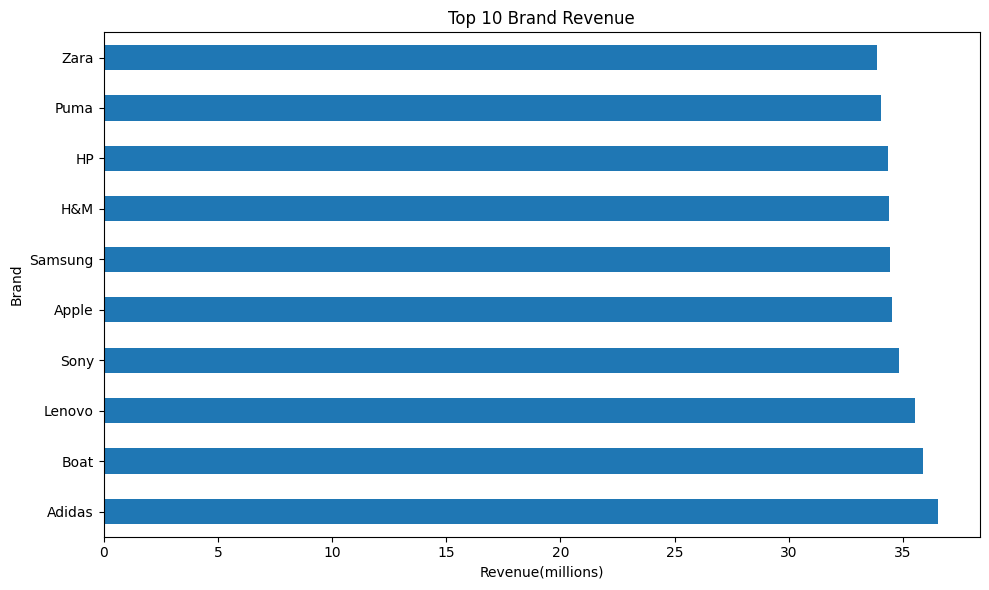

In [22]:
top_10_million = top_10_brands / 1_000_000
plt.figure(figsize = (10,6))
top_10_million.plot(kind="barh")
# plt.barh(
#     top_10_million.index[::-1],
#     top_10_million.values[::-1]
# )
plt.title("Top 10 Brand Revenue")
plt.xlabel("Revenue(millions)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Q2. Create a customer return analysis model to identify which category and location have the highest return
percentage.

In [23]:
print(df["is_returned"].value_counts())

is_returned
False    37050
True      4808
Name: count, dtype: int64


In [24]:
df["is_returned"].dtype

dtype('O')

In [25]:
category_return_rate = (
    df.groupby('category')['is_returned']
      .mean()
      .mul(100)  #multiply every by 100
      .sort_values(ascending=False)
)

print(category_return_rate)

category
Clothing       11.854571
Beauty         11.608324
Sports         11.597505
Home           11.223639
Electronics    11.146953
Name: is_returned, dtype: object


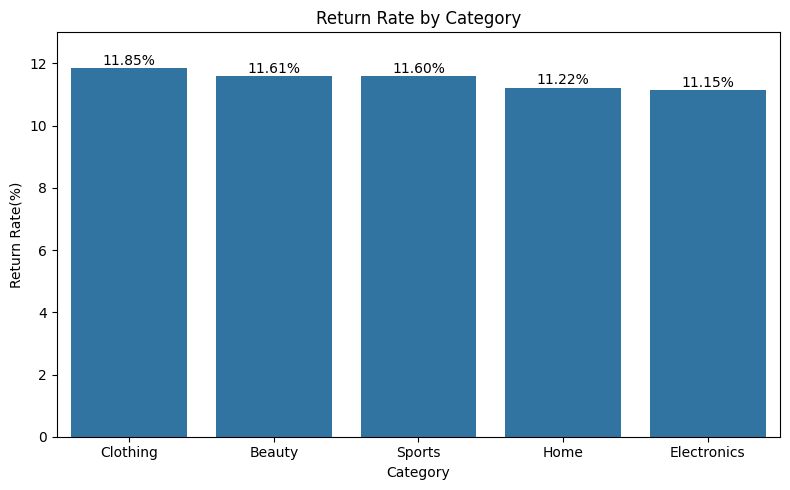

In [26]:
plt.figure(figsize = (8,5))
ax = sns.barplot(
    x=category_return_rate.index,
    y=category_return_rate.values
)
plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate(%)")
# Add values on top of bars
for i, value in enumerate(category_return_rate.values):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}%",
        ha='center'
    )

plt.ylim(0, 13)
plt.tight_layout()
plt.show()

In [27]:
location_return_rate = (df.groupby("location")["is_returned"]
                        .mean()
                        .mul(100)
                        .sort_values(ascending=False))
print(location_return_rate)

location
Bangalore    12.513549
Chennai      11.937819
Hyderabad    11.920134
Mumbai       10.614192
Delhi        10.454708
Name: is_returned, dtype: object


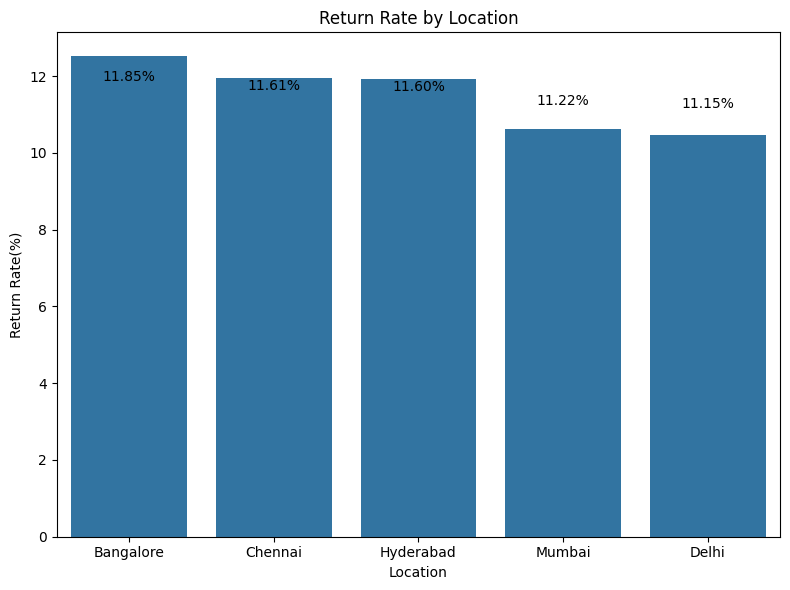

In [28]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=location_return_rate.index,
    y=location_return_rate.values
)
plt.title("Return Rate by Location")
plt.xlabel("Location")
plt.ylabel("Return Rate(%)")
for i, value in enumerate(category_return_rate.values):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}%",
        ha='center'
    )
plt.tight_layout()
plt.show()

In [29]:
category_location_return = (
    df.groupby(["category", "location"])["is_returned"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(category_location_return)

category     location 
Clothing     Bangalore    13.203079
Home         Bangalore    12.956204
Sports       Bangalore    12.806373
             Hyderabad    12.448133
Electronics  Hyderabad    12.336114
Beauty       Chennai      12.238806
Home         Chennai      12.044007
Beauty       Delhi        12.028725
Clothing     Chennai      11.969785
Beauty       Bangalore    11.893204
Electronics  Chennai      11.827957
             Bangalore    11.715976
Clothing     Hyderabad    11.677534
Sports       Chennai      11.595092
Home         Hyderabad    11.566265
Beauty       Hyderabad    11.561743
Clothing     Delhi        11.493582
Sports       Mumbai       11.474435
Clothing     Mumbai       10.900184
Home         Mumbai       10.406977
Beauty       Mumbai       10.317936
Electronics  Mumbai        9.982175
             Delhi         9.848024
Sports       Delhi         9.724663
Home         Delhi         9.135201
Name: is_returned, dtype: object


 q 3.Perform time-series analysis on purchase_date to identify monthly sales trends and seasonal spikes

In [30]:
df["purchase_date"]=pd.to_datetime(df["purchase_date"],format = "%d-%m-%Y")


In [31]:
df["purchase_date"].dtype

dtype('<M8[ns]')

In [32]:
monthly_sales = (df.set_index("purchase_date")
.resample("ME")["final_price"] # m is monthly frequency
                 .sum())

In [33]:
print(monthly_sales)

purchase_date
2024-03-31      325266.72
2024-04-30    16407866.90
2024-05-31    17976615.34
2024-06-30    16755238.20
2024-07-31    18227984.54
2024-08-31    18493351.48
2024-09-30    17772001.85
2024-10-31    16652655.17
2024-11-30    17704983.73
2024-12-31    18914804.75
2025-01-31    18046567.72
2025-02-28    16388659.25
2025-03-31    17373738.32
2025-04-30    16571538.13
2025-05-31    16965704.13
2025-06-30    17028004.67
2025-07-31    17325621.97
2025-08-31    17236226.44
2025-09-30    15568349.55
2025-10-31    18548046.35
2025-11-30    16855001.49
2025-12-31    18132651.90
2026-01-31    17954498.12
2026-02-28    14592729.33
2026-03-31    17541078.29
Name: final_price, dtype: float64


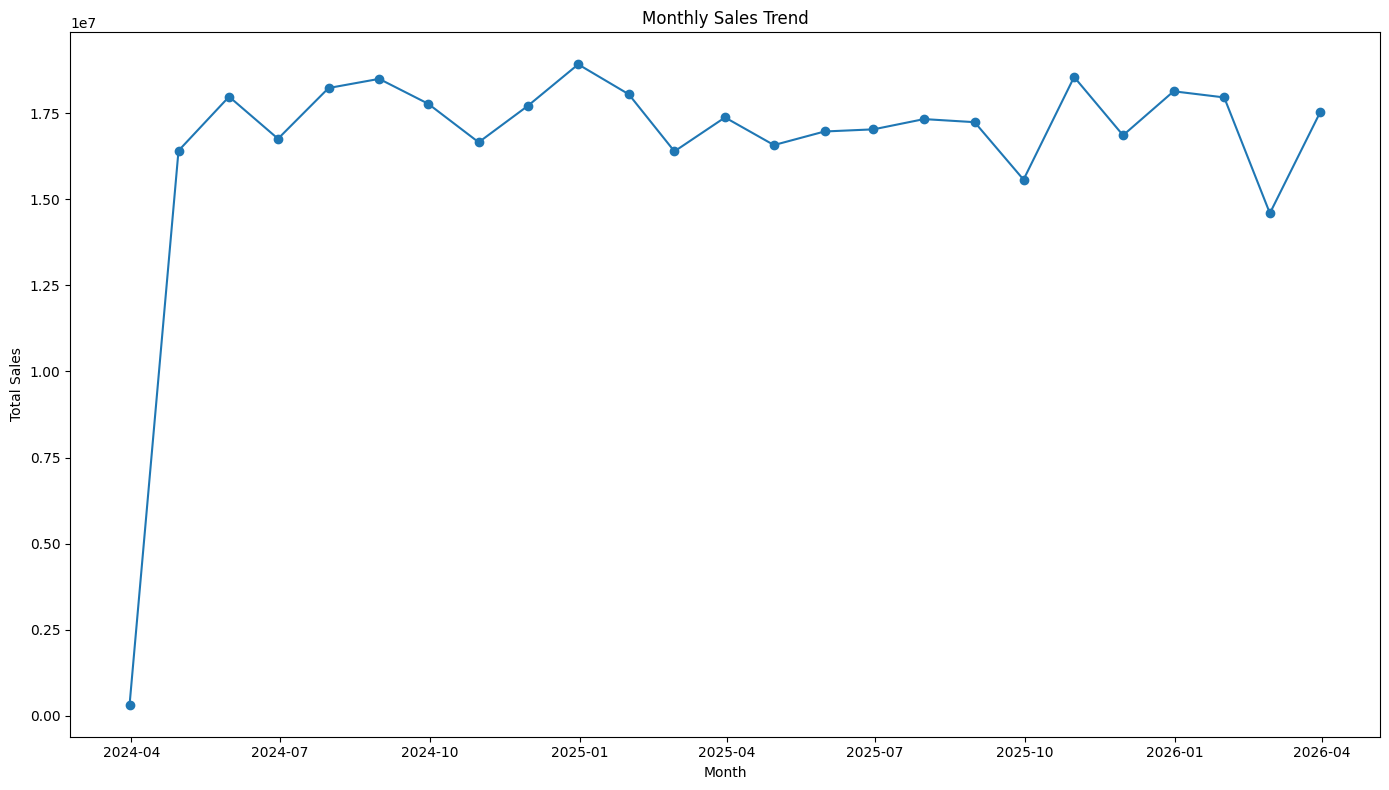

In [34]:
plt.figure(figsize=(14,8))
plt.plot  (
    monthly_sales.index,
    monthly_sales.values,
    marker ="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()


In [35]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest sales month:", highest_month)
print("Revenue:", highest_sales)

Highest sales month: 2024-12-31 00:00:00
Revenue: 18914804.75


In [36]:
lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Lowest Sales Month:",lowest_month)
print("Revenue:",lowest_month)

Lowest Sales Month: 2024-03-31 00:00:00
Revenue: 2024-03-31 00:00:00


In [37]:
seasonal_sales = (
    df.groupby(df["purchase_date"].dt.month)["final_price"]
    .mean()

)
print(seasonal_sales)


purchase_date
1.0     10075.865055
2.0      9882.420600
3.0     10048.498241
4.0      9479.564539
5.0      9649.908719
6.0      9817.856109
7.0      9794.381959
8.0      9889.171857
9.0      9910.924911
10.0    10150.144614
11.0    10158.725814
12.0    10219.988041
Name: final_price, dtype: float64


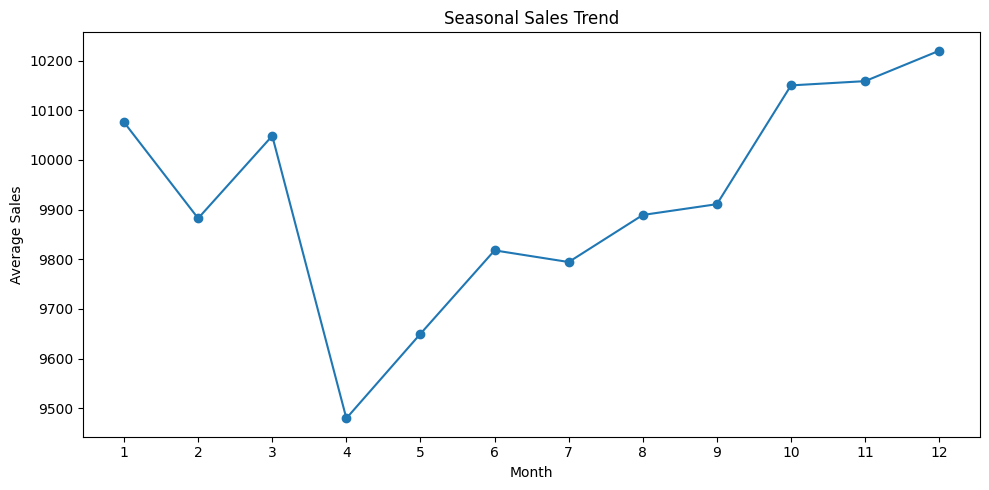

In [38]:
plt.figure(figsize=(10,5))
plt.plot(
    seasonal_sales.index,
    seasonal_sales.values,
    marker="o" #show the individual data points on a graph.
)
plt.title("Seasonal Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

 Q4. Build a correlation heatmap between price, discount, rating, review_count, seller_rating, and shipping_time_days.

In [39]:
corr_columns = [
    "price",
    "discount",
    "rating",
    "seller_rating",
    "shipping_time_days"
]
corr_data = df[corr_columns]

In [40]:
correlation_matrix = corr_data.corr()
print(correlation_matrix)

                       price  discount    rating  seller_rating  \
price               1.000000 -0.211202  0.327722      -0.005170   
discount           -0.211202  1.000000 -0.067763       0.009005   
rating              0.327722 -0.067763  1.000000      -0.000959   
seller_rating      -0.005170  0.009005 -0.000959       1.000000   
shipping_time_days -0.003817 -0.000261  0.000656       0.009928   

                    shipping_time_days  
price                        -0.003817  
discount                     -0.000261  
rating                        0.000656  
seller_rating                 0.009928  
shipping_time_days            1.000000  


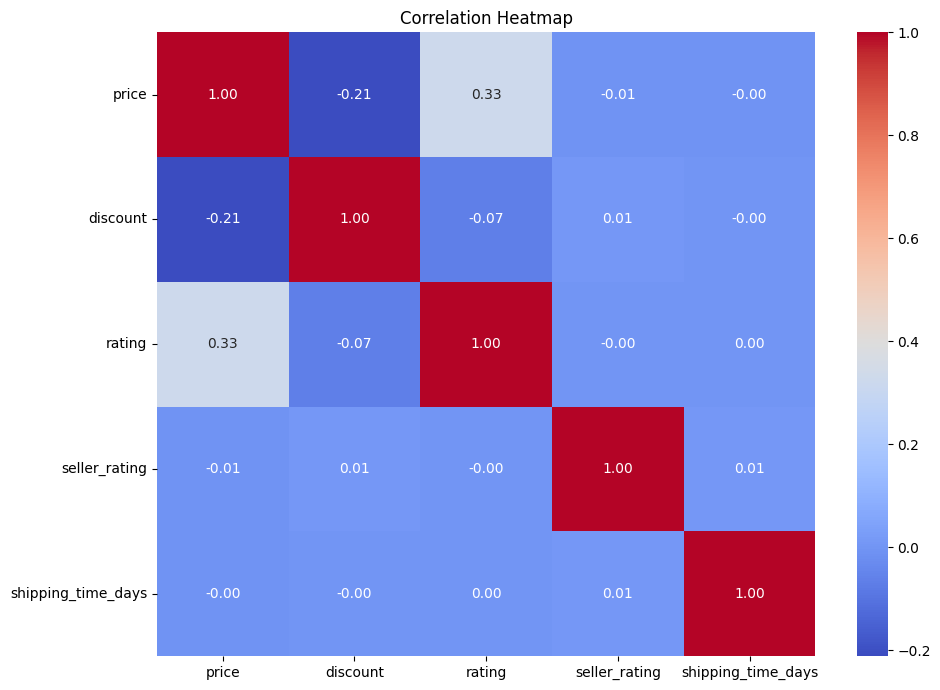

In [41]:
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True, #Displays the actual correlation numbers inside each cell.
    cmap="coolwarm", #Gives a visual distinction between positive and negative correlations.
    fmt=".2f" #Shows values to two decimal places
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Q5. Find products where rating > 4.5, discount > 30%, and review_count > 100, then analyze which category performs
best.

In [47]:
high_performing = df[
    (df["rating"]>4.5) &
    (df["discount"]>30) &
    (df["review_count"]>100)
].copy()
print(high_performing)

       user_id product_id     category subcategory  brand     price  discount  \
323    U772741     P98753         Home   Furniture   Boat  14859.81     49.48   
704    U398911     P37471  Electronics      Mobile   Zara  31838.09     36.22   
1009   U304553     P28764  Electronics      Camera   Sony  75862.66     38.15   
1548   U529080     P11340     Clothing        Kids    H&M    505.16     56.63   
2735   U937003     P21839  Electronics  Headphones  Apple  45416.26     32.90   
...        ...        ...          ...         ...    ...       ...       ...   
41243  U775101     P88152     Clothing         Men     HP   2418.14     47.47   
41365  U616216     P49228  Electronics  Headphones   Sony  68260.25     35.78   
41392  U713064     P74809       Sports     Cycling     LG   7042.87     42.22   
41570  U678328     P86271     Clothing       Women     HP   4367.56     47.06   
41584  U898303     P62371  Electronics      Mobile   Sony  58323.28     39.05   

       final_price  rating 

In [43]:
category_performance = (
    high_performing.groupby("category")
    .agg(
        product_count = ("product_id","count"),
        total_revenue = ("final_price","sum"),
        average_rating = ("rating","mean"),
        average_discount = ("discount","mean")
    )
    .sort_values("total_revenue",ascending= False)
)
print(category_performance)

             product_count  total_revenue  average_rating  average_discount
category                                                                   
Electronics             36     1343247.55        4.897222         34.921667
Home                    26      203000.11        4.711538         40.375385
Sports                  13       71775.12        4.807692         38.436154
Clothing                24       31683.67        4.758333         50.385833
Beauty                  14       22622.90        4.735714         39.462857


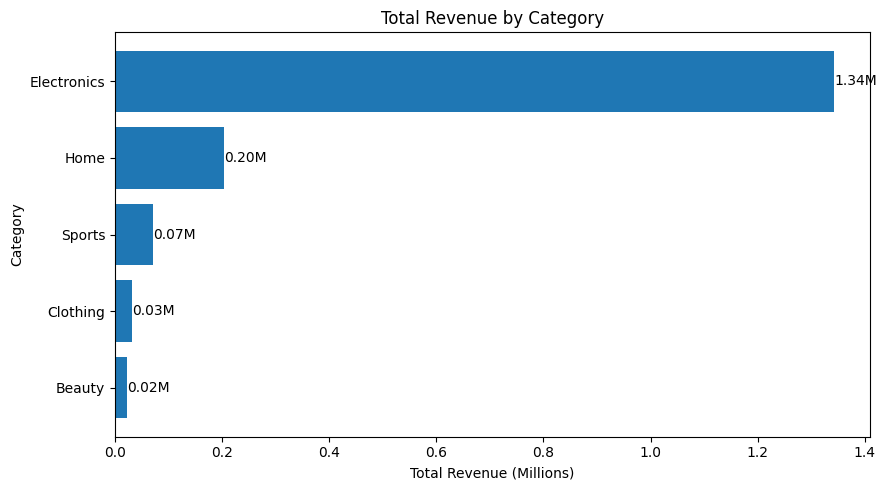

In [50]:
plt.figure(figsize=(9, 5))

revenue_millions = category_performance["total_revenue"] / 1_000_000

bars = plt.barh(
    revenue_millions.index[::-1],
    revenue_millions.values[::-1]
)

plt.title("Total Revenue by Category")
plt.xlabel("Total Revenue (Millions)")
plt.ylabel("Category")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}M",
        va="center"
    )

plt.tight_layout()
plt.show()

Q6.  Create a seller performance score using seller_rating, return rate, delivery delay, and average product rating.

In [51]:
seller_performance = (df.groupby("seller_id")
.agg(
    seller_rating=("seller_rating","mean"),
    avg_product_rating= ("rating","mean"),
    total_orders = ("product_id","count"),
    total_returns = ("is_returned","sum")
)
                      )

In [53]:
seller_performance["return_rate"]= (
    seller_performance["total_returns"] / seller_performance["total_orders"]*
    100
)

In [54]:
delayed_orders = (
    df[df["delivery_status"] == "Delayed"]
    .groupby("seller_id")
    .size()
)

In [56]:
seller_performance["delayed_orders"] = (
    delayed_orders.reindex(seller_performance.index, fill_value=0)
)

In [66]:
seller_performance["delay_rate"] = (
    seller_performance["delayed_orders"]/
    seller_performance["total_orders"]*100
)

In [67]:
seller_performance["seller_rating_score"] = (
    seller_performance["seller_rating"] / 5 * 100
)

seller_performance["product_rating_score"] = (
    seller_performance["avg_product_rating"] / 5 * 100
)

In [68]:
return_min = seller_performance["return_rate"].min()
return_max = seller_performance["return_rate"].max()

seller_performance["return_score"] = (
    1 -
    (seller_performance["return_rate"] - return_min) /
    (return_max - return_min)
) * 100

In [69]:
print(df["Delivery_delay"].value_counts())

Delivery_delay
On Time    29434
Delayed    12425
Name: count, dtype: int64


In [73]:
delay_min = seller_performance["delay_rate"].min()
delay_max = seller_performance["delay_rate"].max()

seller_performance["delay_score"] = (
    1 -
    (seller_performance["delay_rate"] - delay_min) /
    (delay_max - delay_min)
) * 100

In [74]:
seller_performance["performance_score"] = (
    seller_performance["seller_rating_score"] * 0.30 +
    seller_performance["product_rating_score"] * 0.30 +
    seller_performance["return_score"] * 0.20 +
    seller_performance["delay_score"] * 0.20
)

In [75]:
seller_performance = seller_performance.sort_values(
    "performance_score",
    ascending=False
)

In [76]:
print(
    seller_performance[
        [
            "seller_rating",
            "avg_product_rating",
            "return_rate",
            "delay_rate",
            "performance_score"
        ]
    ].head(10)
)

           seller_rating  avg_product_rating return_rate  delay_rate  \
seller_id                                                              
S4569           4.900000            4.700000         0.0         0.0   
S9642           4.600000            5.000000         0.0         0.0   
S2979           4.800000            4.500000         0.0         0.0   
S2987           4.533333            4.533333         0.0         0.0   
S8125           4.800000            4.200000         0.0         0.0   
S5211           4.800000            4.200000         0.0         0.0   
S1937           4.833333            4.100000         0.0         0.0   
S2258           4.600000            4.300000         0.0         0.0   
S7439           4.900000            4.000000         0.0         0.0   
S2512           4.900000            3.900000         0.0         0.0   

          performance_score  
seller_id                    
S4569                  97.6  
S9642                  97.6  
S2979          

In [77]:
def classify_seller(score):
    if score >= 80:
        return "Excellent"
    elif score >= 65:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

In [78]:
seller_performance["performance_category"] = (
    seller_performance["performance_score"]
    .apply(classify_seller)
)

In [79]:
print(
    seller_performance[
        [
            "seller_rating",
            "avg_product_rating",
            "return_rate",
            "delay_rate",
            "performance_score",
            "performance_category"
        ]
    ].head(10)
)

           seller_rating  avg_product_rating return_rate  delay_rate  \
seller_id                                                              
S4569           4.900000            4.700000         0.0         0.0   
S9642           4.600000            5.000000         0.0         0.0   
S2979           4.800000            4.500000         0.0         0.0   
S2987           4.533333            4.533333         0.0         0.0   
S8125           4.800000            4.200000         0.0         0.0   
S5211           4.800000            4.200000         0.0         0.0   
S1937           4.833333            4.100000         0.0         0.0   
S2258           4.600000            4.300000         0.0         0.0   
S7439           4.900000            4.000000         0.0         0.0   
S2512           4.900000            3.900000         0.0         0.0   

          performance_score performance_category  
seller_id                                         
S4569                  97.6      

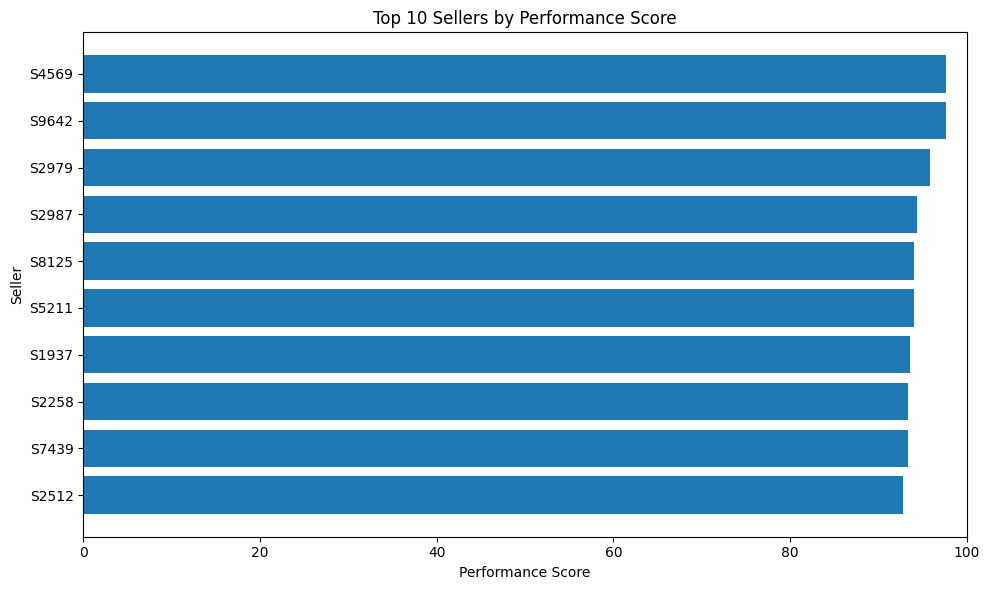

In [80]:
top_sellers = seller_performance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers.index[::-1],
    top_sellers["performance_score"][::-1]
)

plt.title("Top 10 Sellers by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Seller")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

 Q 7. Detect outliers in product pricing using IQR or Z-score method and identify suspicious products.

In [81]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 2722.7825000000003
Q3: 14103.7375
IQR: 11380.954999999998


In [82]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -14348.649999999994
Upper Bound: 31175.169999999995


In [83]:
price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
].copy()

In [84]:
print(price_outliers.shape)

(5379, 25)


In [85]:
print(
    price_outliers[
        [
            "product_id",
            "category",
            "subcategory",
            "brand",
            "price",
            "discount",
            "final_price",
            "rating"
        ]
    ].sort_values("price", ascending=False).head(20)
)

      product_id     category subcategory    brand     price  discount  \
15296     P15763  Electronics  Headphones       LG  79981.50     18.16   
29270     P39134  Electronics      Laptop       HP  79971.82     16.44   
23659     P51148  Electronics  Headphones     Boat  79966.08     30.96   
21817     P57843  Electronics      Camera   Adidas  79958.16     25.30   
41179     P86176  Electronics      Laptop     Boat  79940.08     32.00   
32601     P53764  Electronics      Laptop  Samsung  79935.35     18.86   
15613     P27369  Electronics      Laptop       LG  79918.95     20.88   
17006     P42180  Electronics      Mobile     Nike  79914.96     19.55   
13590     P22462  Electronics      Mobile   Lenovo  79895.84     30.46   
27876     P68005  Electronics      Laptop     Boat  79886.28     22.42   
3907      P99784  Electronics      Mobile     Sony  79885.53      9.14   
37715     P25109  Electronics  Headphones       LG  79879.30     21.87   
23645     P67073  Electronics      Lap

In [86]:
outlier_percentage = (
    len(price_outliers) / len(df)
) * 100

print("Outlier Percentage:", outlier_percentage)

Outlier Percentage: 12.850283093241597


In [88]:
print(df["price"].dtype)
print(df["price"].head())

float64
0    33090.51
1     9368.97
2    14756.85
3      668.83
4    10881.29
Name: price, dtype: float64


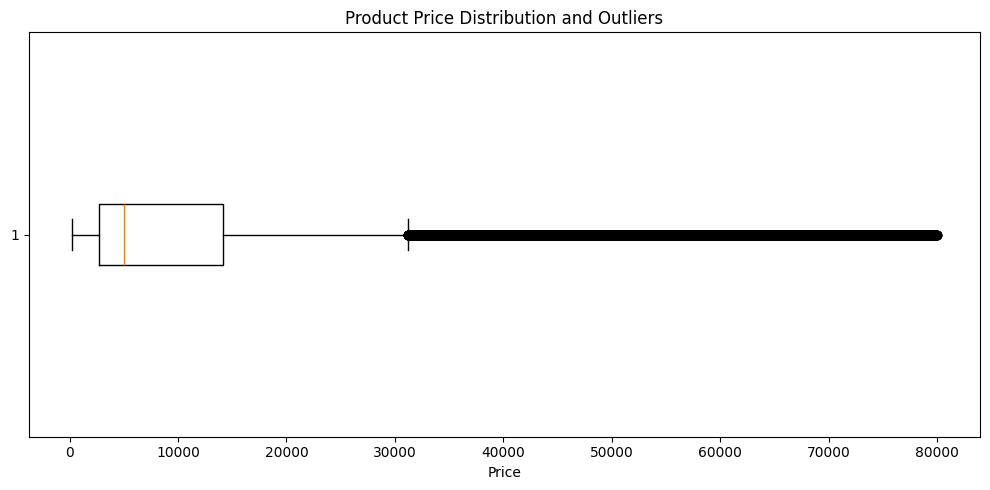

In [89]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["price"].dropna().values,
    vert=False
)

plt.title("Product Price Distribution and Outliers")
plt.xlabel("Price")

plt.tight_layout()
plt.show()

In [91]:
print("Number of price outliers:", len(price_outliers))

Number of price outliers: 5379


In [93]:
print(
    "Percentage of price outliers:",
    round(len(price_outliers) / len(df) * 100, 2),
    "%"
)

Percentage of price outliers: 12.85 %


In [94]:
top_outliers = price_outliers.sort_values(
    "price",
    ascending=False
)

print(
    top_outliers[
        [
            "product_id",
            "category",
            "subcategory",
            "brand",
            "price",
            "discount",
            "final_price",
            "rating"
        ]
    ].head(10)
)

      product_id     category subcategory    brand     price  discount  \
15296     P15763  Electronics  Headphones       LG  79981.50     18.16   
29270     P39134  Electronics      Laptop       HP  79971.82     16.44   
23659     P51148  Electronics  Headphones     Boat  79966.08     30.96   
21817     P57843  Electronics      Camera   Adidas  79958.16     25.30   
41179     P86176  Electronics      Laptop     Boat  79940.08     32.00   
32601     P53764  Electronics      Laptop  Samsung  79935.35     18.86   
15613     P27369  Electronics      Laptop       LG  79918.95     20.88   
17006     P42180  Electronics      Mobile     Nike  79914.96     19.55   
13590     P22462  Electronics      Mobile   Lenovo  79895.84     30.46   
27876     P68005  Electronics      Laptop     Boat  79886.28     22.42   

       final_price  rating  
15296     65457.70     5.0  
29270     66824.10     4.8  
23659     55207.99     3.8  
21817     59729.06     4.4  
41179     54358.47     5.0  
32601     6

In [95]:
#outliers percentage by category
outlier_by_category = (
    price_outliers["category"]
    .value_counts()
)

print(outlier_by_category)

category
Electronics    5379
Name: count, dtype: int64


In [96]:
category_outlier_percentage = (
    df.groupby("category")["price"]
    .apply(lambda x: (x > upper_bound).mean() * 100)
    .sort_values(ascending=False)
)

print(category_outlier_percentage)

category
Electronics    64.265233
Beauty          0.000000
Clothing        0.000000
Home            0.000000
Sports          0.000000
Name: price, dtype: float64


Q8.  Build a predictive model to predict whether a product will be returned using classification algorithms


In [155]:

df = pd.read_csv("/content/amazon_ecommerce_1M_clean.csv")
print(df.shape)

(1000000, 25)


In [156]:
print(df["is_returned"].value_counts())
print(df["is_returned"].value_counts(normalize=True) * 100)

is_returned
False    884010
True     115990
Name: count, dtype: int64
is_returned
False    88.401
True     11.599
Name: proportion, dtype: float64


In [158]:
features = [
    "price",
    "discount",
    "rating",
    "review_count",
    "stock",
    "seller_rating",
    "shipping_time_days",
    "category",
    "subcategory",
    "brand",
    "location",
    "device",
    "payment_method"
]

In [159]:
target = "is_returned"

In [160]:
X = df[features]
y = df[target]

In [161]:
print(X.shape)
print(y.shape)

(1000000, 13)
(1000000,)


In [162]:
numeric_features = [
    "price",
    "discount",
    "rating",
    "review_count",
    "stock",
    "seller_rating",
    "shipping_time_days"
]

In [163]:
categorical_features = [
    "category",
    "subcategory",
    "brand",
    "location",
    "device",
    "payment_method"
]

In [164]:
from sklearn.model_selection import train_test_split

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [176]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [178]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['price', 'discount',
                                                   'rating', 'review_count',
                                                   'stock', 'seller_rating',
                                                   'shipping_time_days']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'subcategory',
                                                   'brand', 'location',
                                                   'device',
                                                   'payment_method'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [179]:
print("Model trained successfully!")

Model trained successfully!


In [180]:
y_pred = model.predict(X_test)

In [181]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [182]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.54594
Precision: 0.13424212917883804
Recall: 0.5348736960082766
F1 Score: 0.21461929636420243


In [183]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.55      0.68    176802
        True       0.13      0.53      0.21     23198

    accuracy                           0.55    200000
   macro avg       0.52      0.54      0.45    200000
weighted avg       0.81      0.55      0.63    200000



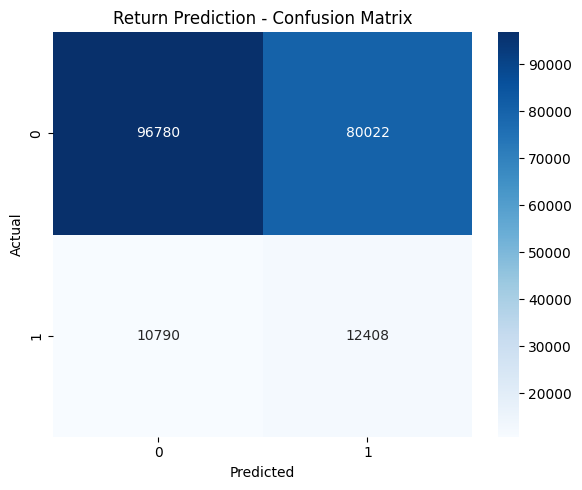

In [184]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Return Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [185]:
logistic_results = {
    "Accuracy": 0.5459,
    "Precision": 0.1342,
    "Recall": 0.5349,
    "F1": 0.2146
}

print(logistic_results)

{'Accuracy': 0.5459, 'Precision': 0.1342, 'Recall': 0.5349, 'F1': 0.2146}


Model 2: Random Forest

In [186]:
from sklearn.ensemble import RandomForestClassifier

In [189]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [190]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['price', 'discount',
                                                   'rating', 'review_count',
                                                   'stock', 'seller_rating',
                                                   'shipping_time_days']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'subcategory',
                                                   'brand', 'location',
                                                   'device',
                                                   'payment_method'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_jobs=-1, random_state=42))])

In [191]:
rf_pred = rf_model.predict(X_test)

In [192]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Random Forest Results")
print("---------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.81495
Precision: 0.22636500515096283
Recall   : 0.24627123027847228
F1 Score : 0.23589891816004624

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.89      0.89    176802
        True       0.23      0.25      0.24     23198

    accuracy                           0.81    200000
   macro avg       0.56      0.57      0.57    200000
weighted avg       0.82      0.81      0.82    200000



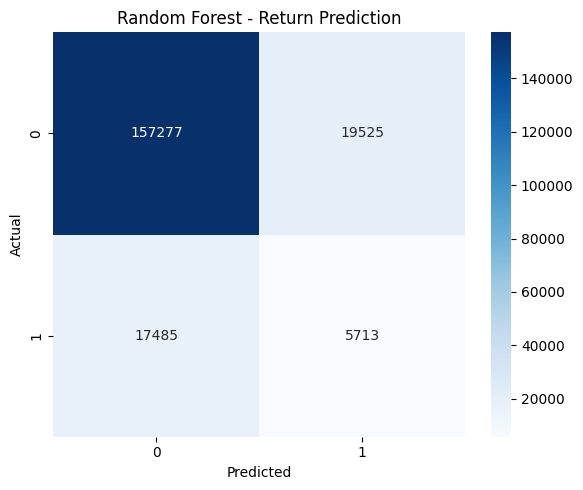

In [193]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Return Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [194]:
rf_model.predict(X_test)

array([False, False, False, ..., False, False, False])

In [195]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [196]:
rf_pred_30 = (rf_prob >= 0.30).astype(int)

In [197]:
print("Accuracy :", accuracy_score(y_test, rf_pred_30))
print("Precision:", precision_score(y_test, rf_pred_30))
print("Recall   :", recall_score(y_test, rf_pred_30))
print("F1 Score :", f1_score(y_test, rf_pred_30))

Accuracy : 0.11599
Precision: 0.11599
Recall   : 1.0
F1 Score : 0.2078692461401984


In [198]:
for threshold in [0.2, 0.3, 0.4, 0.5]:

    predictions = (rf_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision_score(y_test, predictions):.3f} | "
        f"Recall: {recall_score(y_test, predictions):.3f} | "
        f"F1: {f1_score(y_test, predictions):.3f}"
    )

Threshold: 0.2 | Precision: 0.116 | Recall: 1.000 | F1: 0.208
Threshold: 0.3 | Precision: 0.116 | Recall: 1.000 | F1: 0.208
Threshold: 0.4 | Precision: 0.116 | Recall: 0.999 | F1: 0.208
Threshold: 0.5 | Precision: 0.226 | Recall: 0.246 | F1: 0.236


Q9. Analyze how shipping_time_days affects customer ratings and delivery status

In [199]:
print(
    df.groupby("shipping_time_days")["rating"]
      .mean()
      .sort_index()
)

shipping_time_days
1    3.927407
2    3.926675
3    3.927770
4    3.926501
5    3.927911
6    3.926898
Name: rating, dtype: float64


In [200]:
print(
    df.groupby("delivery_status")["shipping_time_days"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

                  count      mean  median
delivery_status                          
Returned         115990  3.409690     3.0
Delayed          294983  3.140581     3.0
Delivered        295234  3.131574     3.0
In Transit       293793  3.131232     3.0


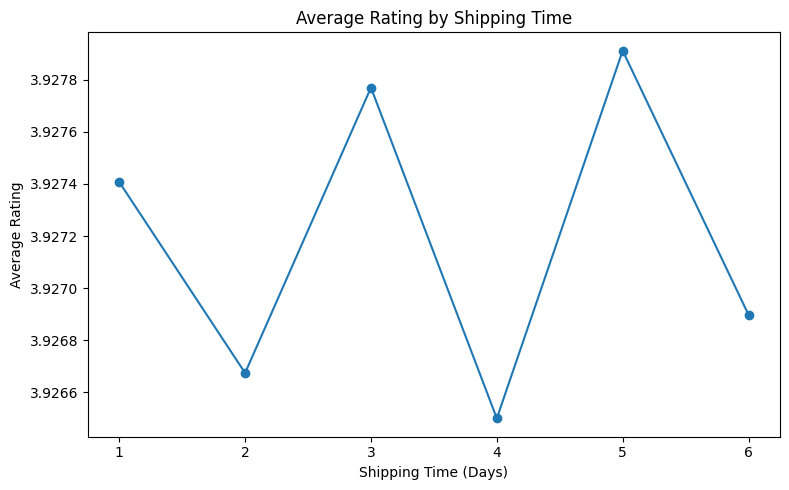

In [201]:
shipping_rating = (
    df.groupby("shipping_time_days")["rating"]
      .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    shipping_rating.index,
    shipping_rating.values,
    marker="o"
)

plt.title("Average Rating by Shipping Time")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Average Rating")

plt.xticks(shipping_rating.index)

plt.tight_layout()
plt.show()

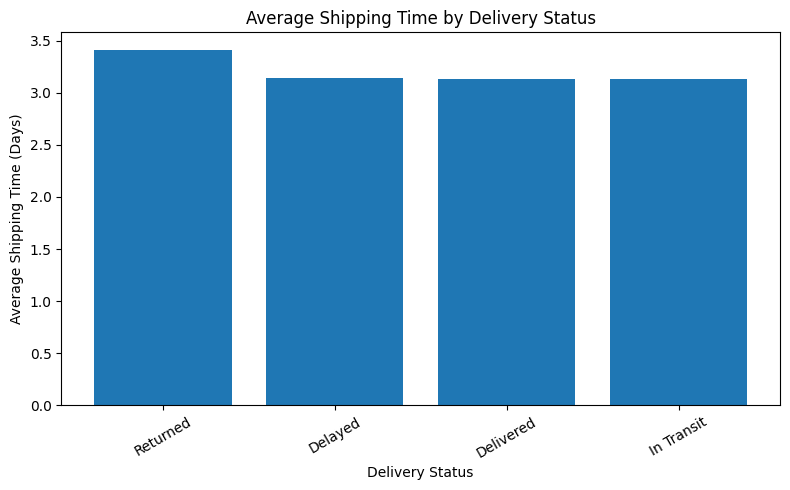

In [202]:
status_shipping = (
    df.groupby("delivery_status")["shipping_time_days"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    status_shipping.index,
    status_shipping.values
)

plt.title("Average Shipping Time by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Shipping Time (Days)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [203]:
shipping_return_rate = (
    df.groupby("shipping_time_days")["is_returned"]
      .mean()
      .mul(100)
)

print(shipping_return_rate)

shipping_time_days
1    10.670805
2    10.574051
3    10.500015
4    10.572045
5    10.616858
6    20.671622
Name: is_returned, dtype: float64


In [204]:
shipping_analysis = (
    df.groupby("shipping_time_days")
      .agg(
          orders=("is_returned", "count"),
          returns=("is_returned", "sum"),
          return_rate=("is_returned", "mean")
      )
)

shipping_analysis["return_rate"] *= 100

print(shipping_analysis)

                    orders  returns  return_rate
shipping_time_days                              
1                   232944    24857    10.670805
2                   167372    17698    10.574051
3                   166095    17440    10.500015
4                   167347    17692    10.572045
5                   166424    17669    10.616858
6                    99818    20634    20.671622


In [205]:
ratio = 20.671622 / 10.500015
print(round(ratio, 2))

1.97


Q 10. Create an advanced customer purchasing behavior analysis based on device, payment_method, location, and
category purchased

In [206]:
device_analysis = (
    df.groupby("device")
      .agg(
          orders=("user_id", "count"),
          revenue=("Revenue", "sum"),
          avg_rating=("rating", "mean"),
          returns=("is_returned", "sum")
    )
)

device_analysis["return_rate"] = (
    device_analysis["returns"] /
    device_analysis["orders"] * 100
)

print(device_analysis.sort_values("revenue", ascending=False))

            orders       revenue  avg_rating  returns  return_rate
device                                                            
Mobile App  333637  3.318986e+09    3.926906    38699    11.599133
Web         333297  3.318191e+09    3.928095    38434    11.531457
Tablet      333066  3.301700e+09    3.926677    38857    11.666456


In [207]:
payment_analysis = (
    df.groupby("payment_method")
      .agg(
          orders=("user_id", "count"),
          revenue=("Revenue", "sum"),
          avg_rating=("rating", "mean"),
          returns=("is_returned", "sum")
    )
)

payment_analysis["return_rate"] = (
    payment_analysis["returns"] /
    payment_analysis["orders"] * 100
)

print(payment_analysis.sort_values("revenue", ascending=False))

                  orders       revenue  avg_rating  returns  return_rate
payment_method                                                          
Credit Card       250324  2.492119e+09    3.927013    29170    11.652898
Cash on Delivery  250388  2.485300e+09    3.927576    28900    11.542087
Debit Card        249337  2.482684e+09    3.927158    28967    11.617610
UPI               249951  2.478775e+09    3.927157    28953    11.583470


In [208]:
location_analysis = (
    df.groupby("location")
      .agg(
          orders=("user_id", "count"),
          revenue=("Revenue", "sum"),
          avg_rating=("rating", "mean"),
          returns=("is_returned", "sum")
      )
)

location_analysis["return_rate"] = (
    location_analysis["returns"] /
    location_analysis["orders"] * 100
)

print(
    location_analysis
    .sort_values("revenue", ascending=False)
)

           orders       revenue  avg_rating  returns  return_rate
location                                                         
Delhi      200649  2.000521e+09    3.927912    21272    10.601598
Bangalore  200270  1.990174e+09    3.927302    24433    12.200030
Mumbai     199874  1.988988e+09    3.928245    21476    10.744769
Chennai    199902  1.981130e+09    3.926492    24429    12.220488
Hyderabad  199305  1.978064e+09    3.926173    24380    12.232508


In [213]:
top_location_categories = location_category.sort_values(
    "revenue",
    ascending=False
).head(10)

print(top_location_categories)

                       orders       revenue  avg_rating  returns  return_rate
location  category                                                           
Delhi     Electronics   40307  1.326760e+09    4.207979     4064    10.082616
Bangalore Electronics   39980  1.318535e+09    4.206973     4832    12.086043
Mumbai    Electronics   39957  1.315650e+09    4.206459     4183    10.468754
Hyderabad Electronics   39910  1.309197e+09    4.203448     4747    11.894262
Chennai   Electronics   39884  1.308906e+09    4.205581     4725    11.846856
Delhi     Home          40479  3.078724e+08    3.900482     4253    10.506682
Mumbai    Home          40267  3.078497e+08    3.906117     4195    10.417960
Bangalore Home          40253  3.057276e+08    3.904514     4904    12.182943
Chennai   Home          40027  3.054073e+08    3.899620     4970    12.416619
Hyderabad Home          39896  3.031207e+08    3.900870     4953    12.414778


In [214]:
category_analysis = (
    df.groupby("category")
      .agg(
          orders=("user_id", "count"),
          revenue=("Revenue", "sum"),
          avg_rating=("rating", "mean"),
          returns=("is_returned", "sum")
      )
)

category_analysis["return_rate"] = (
    category_analysis["returns"] /
    category_analysis["orders"] * 100
)

print(category_analysis.sort_values("revenue", ascending=False))

             orders       revenue  avg_rating  returns  return_rate
category                                                           
Electronics  200038  6.579048e+09    4.206092    22551    11.273358
Home         200922  1.529978e+09    3.902324    23275    11.584097
Sports       199889  1.124849e+09    3.876259    23279    11.645964
Beauty       199327  3.759517e+08    3.824287    23433    11.756059
Clothing     199824  3.290504e+08    3.826767    23452    11.736328


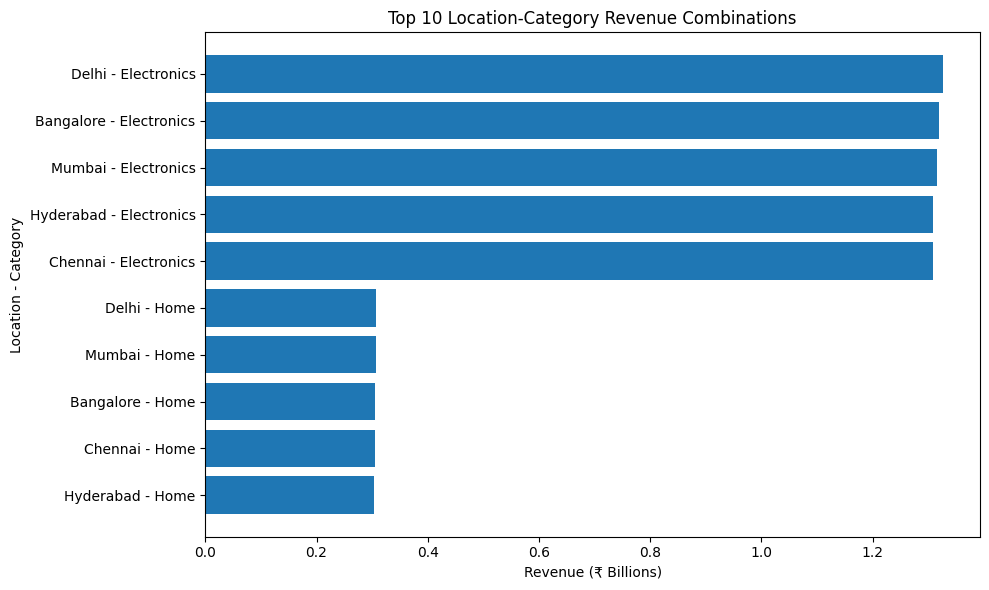

In [216]:
top_combinations = (
    location_category
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

labels = [
    f"{location} - {category}"
    for location, category in top_combinations.index
]

plt.barh(
    labels[::-1],
    (top_combinations["revenue"] / 1_000_000_000)[::-1]
)

plt.title("Top 10 Location-Category Revenue Combinations")
plt.xlabel("Revenue (₹ Billions)")
plt.ylabel("Location - Category")

plt.tight_layout()
plt.show()